# Retail Case Study — Customer Analysis

**Role:** Data Analyst  
**Objective:** Analyze customer transactions, product categories, store performance, customer demographics, and returns using the three supplied datasets.

This notebook follows the questions and terminology in the supplied AnalytixLabs case study. The case study asks us to create `Customer_Final`, keep customers who have transactions, prepare a summary report, visualize the variables, and answer business questions 4–11.

> **Note on Q11:** The case study does not specify the reference date for calculating age 25–35. This notebook uses **1 January 2014** as the age reference date and states that assumption explicitly.


## 1. Import libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


## 2. Load the datasets

In [6]:
customer = pd.read_csv(r"C:\Users\hp\Downloads\Python Foundation Case Study 1 - Retail Case Study (1)\Case Study 1 - Retail Case Study\Customer.csv")
transactions = pd.read_csv(r"C:\Users\hp\Downloads\Python Foundation Case Study 1 - Retail Case Study (1)\Case Study 1 - Retail Case Study\Transactions.csv")
prod_cat_info = pd.read_csv(r"C:\Users\hp\Downloads\Python Foundation Case Study 1 - Retail Case Study (1)\Case Study 1 - Retail Case Study\prod_cat_info.csv")

print("Customer shape:", customer.shape)
print("Transactions shape:", transactions.shape)
print("Product hierarchy shape:", prod_cat_info.shape)


Customer shape: (5647, 4)
Transactions shape: (23053, 10)
Product hierarchy shape: (23, 4)


## 3. Initial inspection

In [7]:
display(customer.head())
display(transactions.head())
display(prod_cat_info.head())

print("\nCustomer columns:")
print(customer.columns.tolist())

print("\nTransaction columns:")
print(transactions.columns.tolist())

print("\nProduct hierarchy columns:")
print(prod_cat_info.columns.tolist())


,customer_Id,DOB,Gender,city_code
0,268408,02-01-1970,M,4.00
1,269696,07-01-1970,F,8.00
2,268159,08-01-1970,F,8.00
3,270181,10-01-1970,F,2.00
4,268073,11-01-1970,M,1.00


,transaction_id,cust_id,tran_date,prod_subcat_code,prod_cat_code,Qty,Rate,Tax,total_amt,Store_type
0,80712190438,270351,28-02-2014,1,1,-5,-772,405.30,"-4,265.30",e-Shop
1,29258453508,270384,27-02-2014,5,3,-5,-1497,785.92,"-8,270.92",e-Shop
2,51750724947,273420,24-02-2014,6,5,-2,-791,166.11,"-1,748.11",TeleShop
3,93274880719,271509,24-02-2014,11,6,-3,-1363,429.35,"-4,518.35",e-Shop
4,51750724947,273420,23-02-2014,6,5,-2,-791,166.11,"-1,748.11",TeleShop


,prod_cat_code,prod_cat,prod_sub_cat_code,prod_subcat
0,1,Clothing,4,Mens
1,1,Clothing,1,Women
2,1,Clothing,3,Kids
3,2,Footwear,1,Mens
4,2,Footwear,3,Women



Customer columns:
['customer_Id', 'DOB', 'Gender', 'city_code']

Transaction columns:
['transaction_id', 'cust_id', 'tran_date', 'prod_subcat_code', 'prod_cat_code', 'Qty', 'Rate', 'Tax', 'total_amt', 'Store_type']

Product hierarchy columns:
['prod_cat_code', 'prod_cat', 'prod_sub_cat_code', 'prod_subcat']


## 4. Data preparation

In [8]:
# Align merge keys
customer = customer.rename(columns={"customer_Id": "cust_id"})
prod_cat_info = prod_cat_info.rename(columns={"prod_sub_cat_code": "prod_subcat_code"})

# Convert dates
transactions["tran_date"] = pd.to_datetime(
    transactions["tran_date"], dayfirst=True, format="mixed", errors="coerce"
)
customer["DOB"] = pd.to_datetime(
    customer["DOB"], dayfirst=True, format="mixed", errors="coerce"
)

print("Missing transaction dates:", transactions["tran_date"].isna().sum())
print("Missing DOB values:", customer["DOB"].isna().sum())


Missing transaction dates: 0
Missing DOB values: 0


## 5. Create `Customer_Final`

In [9]:
# The case study asks us to keep customers who have done transactions,
# therefore an INNER JOIN is appropriate.

Customer_Final = (
    transactions
    .merge(customer, on="cust_id", how="inner")
    .merge(
        prod_cat_info,
        on=["prod_cat_code", "prod_subcat_code"],
        how="inner"
    )
)

print("Customer_Final shape:", Customer_Final.shape)
display(Customer_Final.head())


Customer_Final shape: (23053, 15)


,transaction_id,cust_id,tran_date,prod_subcat_code,prod_cat_code,Qty,Rate,Tax,total_amt,Store_type,DOB,Gender,city_code,prod_cat,prod_subcat
0,80712190438,270351,2014-02-28,1,1,-5,-772,405.30,"-4,265.30",e-Shop,1981-09-26,M,5.00,Clothing,Women
1,29258453508,270384,2014-02-27,5,3,-5,-1497,785.92,"-8,270.92",e-Shop,1973-05-11,F,8.00,Electronics,Computers
2,51750724947,273420,2014-02-24,6,5,-2,-791,166.11,"-1,748.11",TeleShop,1992-07-27,M,8.00,Books,DIY
3,93274880719,271509,2014-02-24,11,6,-3,-1363,429.35,"-4,518.35",e-Shop,1981-06-08,M,3.00,Home and kitchen,Bath
4,51750724947,273420,2014-02-23,6,5,-2,-791,166.11,"-1,748.11",TeleShop,1992-07-27,M,8.00,Books,DIY


## 6. Data quality checks

In [10]:
print("Duplicate rows:", Customer_Final.duplicated().sum())
print("\nMissing values:")
display(Customer_Final.isna().sum().sort_values(ascending=False).to_frame("missing"))

print("\nData types:")
display(Customer_Final.dtypes.to_frame("dtype"))


Duplicate rows: 13

Missing values:


,missing
Gender,9
city_code,8
transaction_id,0
cust_id,0
tran_date,0
prod_subcat_code,0
prod_cat_code,0
Qty,0
Rate,0
Tax,0



Data types:


,dtype
transaction_id,int64
cust_id,int64
tran_date,datetime64[ns]
prod_subcat_code,int64
prod_cat_code,int64
Qty,int64
Rate,int64
Tax,float64
total_amt,float64
Store_type,object


## 7. Summary report — column names and data types

In [11]:
summary = pd.DataFrame({
    "column": Customer_Final.columns,
    "dtype": Customer_Final.dtypes.astype(str).values
})
display(summary)


,column,dtype
0,transaction_id,int64
1,cust_id,int64
2,tran_date,datetime64[ns]
3,prod_subcat_code,int64
4,prod_cat_code,int64
5,Qty,int64
6,Rate,int64
7,Tax,float64
8,total_amt,float64
9,Store_type,object


## 8. Top 10 and Bottom 10 observations

In [12]:
print("Top 10 observations")
display(Customer_Final.head(10))

print("Bottom 10 observations")
display(Customer_Final.tail(10))


Top 10 observations


,transaction_id,cust_id,tran_date,prod_subcat_code,prod_cat_code,Qty,Rate,Tax,total_amt,Store_type,DOB,Gender,city_code,prod_cat,prod_subcat
0,80712190438,270351,2014-02-28,1,1,-5,-772,405.30,"-4,265.30",e-Shop,1981-09-26,M,5.00,Clothing,Women
1,29258453508,270384,2014-02-27,5,3,-5,-1497,785.92,"-8,270.92",e-Shop,1973-05-11,F,8.00,Electronics,Computers
2,51750724947,273420,2014-02-24,6,5,-2,-791,166.11,"-1,748.11",TeleShop,1992-07-27,M,8.00,Books,DIY
3,93274880719,271509,2014-02-24,11,6,-3,-1363,429.35,"-4,518.35",e-Shop,1981-06-08,M,3.00,Home and kitchen,Bath
4,51750724947,273420,2014-02-23,6,5,-2,-791,166.11,"-1,748.11",TeleShop,1992-07-27,M,8.00,Books,DIY
5,97439039119,272357,2014-02-23,8,3,-2,-824,173.04,"-1,821.04",TeleShop,1982-10-09,F,6.00,Electronics,Personal Appliances
6,45649838090,273667,2014-02-22,11,6,-1,-1450,152.25,"-1,602.25",e-Shop,1981-05-29,M,9.00,Home and kitchen,Bath
7,22643667930,271489,2014-02-22,12,6,-1,-1225,128.62,"-1,353.62",TeleShop,1971-04-21,M,9.00,Home and kitchen,Tools
8,79792372943,275108,2014-02-22,3,1,-3,-908,286.02,"-3,010.02",MBR,1971-11-04,F,8.00,Clothing,Kids
9,50076728598,269014,2014-02-21,8,3,-4,-581,244.02,"-2,568.02",e-Shop,1979-11-27,F,3.00,Electronics,Personal Appliances


Bottom 10 observations


,transaction_id,cust_id,tran_date,prod_subcat_code,prod_cat_code,Qty,Rate,Tax,total_amt,Store_type,DOB,Gender,city_code,prod_cat,prod_subcat
23043,49882891062,271982,2011-01-25,10,5,4,1330,558.60,"5,878.60",e-Shop,1976-08-10,M,8.00,Books,Non-Fiction
23044,14787475597,273982,2011-01-25,4,3,5,969,508.73,"5,353.73",e-Shop,1991-10-12,M,4.00,Electronics,Mobiles
23045,50691119572,273031,2011-01-25,6,5,1,1148,120.54,"1,268.54",TeleShop,1980-01-17,F,8.00,Books,DIY
23046,40893803228,272049,2011-01-25,11,6,3,1077,339.25,"3,570.26",e-Shop,1975-06-28,F,6.00,Home and kitchen,Bath
23047,30856003613,266866,2011-01-25,4,2,2,444,93.24,981.24,TeleShop,1974-04-18,M,4.00,Footwear,Kids
23048,94340757522,274550,2011-01-25,12,5,1,1264,132.72,"1,396.72",e-Shop,1972-02-21,M,7.00,Books,Academic
23049,89780862956,270022,2011-01-25,4,1,1,677,71.08,748.09,e-Shop,1984-04-27,M,9.00,Clothing,Mens
23050,85115299378,271020,2011-01-25,2,6,4,1052,441.84,"4,649.84",MBR,1976-06-20,M,8.00,Home and kitchen,Furnishing
23051,72870271171,270911,2011-01-25,11,5,3,1142,359.73,"3,785.73",TeleShop,1970-05-22,M,2.00,Books,Children
23052,77960931771,271961,2011-01-25,11,5,1,447,46.94,493.94,TeleShop,1982-01-15,M,1.00,Books,Children


## 9. Five-number summary for continuous variables

In [13]:
continuous_cols = Customer_Final.select_dtypes(include=np.number).columns

five_number = Customer_Final[continuous_cols].describe().T[
    ["min", "25%", "50%", "75%", "max"]
]
five_number.columns = ["Minimum", "Q1", "Median", "Q3", "Maximum"]
display(five_number)


,Minimum,Q1,Median,Q3,Maximum
transaction_id,"3,268,991.00","24,938,639,453.00","50,093,131,361.00","75,329,995,679.00","99,987,549,630.00"
cust_id,"266,783.00","268,935.00","270,980.00","273,114.00","275,265.00"
prod_subcat_code,1.00,3.00,5.00,10.00,12.00
prod_cat_code,1.00,2.00,4.00,5.00,6.00
Qty,-5.00,1.00,3.00,4.00,5.00
Rate,"-1,499.00",312.00,710.00,"1,109.00","1,500.00"
Tax,7.35,98.28,199.08,365.71,787.50
total_amt,"-8,270.92",762.45,"1,754.74","3,569.15","8,287.50"
city_code,1.00,3.00,5.00,8.00,10.00


## 10. Frequency tables for categorical variables

In [14]:
categorical_cols = Customer_Final.select_dtypes(include=["object"]).columns

for col in categorical_cols:
    print(f"\nFrequency table: {col}")
    display(Customer_Final[col].value_counts(dropna=False).to_frame("frequency"))



Frequency table: Store_type


,frequency
Store_type,
e-Shop,9311
MBR,4661
Flagship store,4577
TeleShop,4504



Frequency table: Gender


,frequency
Gender,
M,11811
F,11233
NaN,9



Frequency table: prod_cat


,frequency
prod_cat,
Books,6069
Electronics,4898
Home and kitchen,4129
Footwear,2999
Clothing,2960
Bags,1998



Frequency table: prod_subcat


,frequency
prod_subcat,
Women,3048
Mens,2912
Kids,1997
Tools,1062
Fiction,1043
Kitchen,1037
Children,1035
Mobiles,1031
Comics,1031


## 11. Histograms for continuous variables

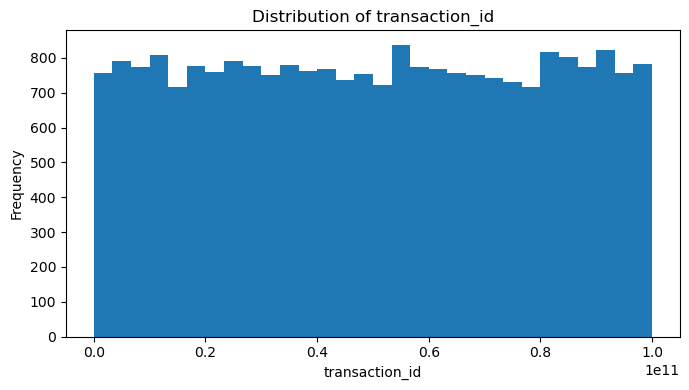

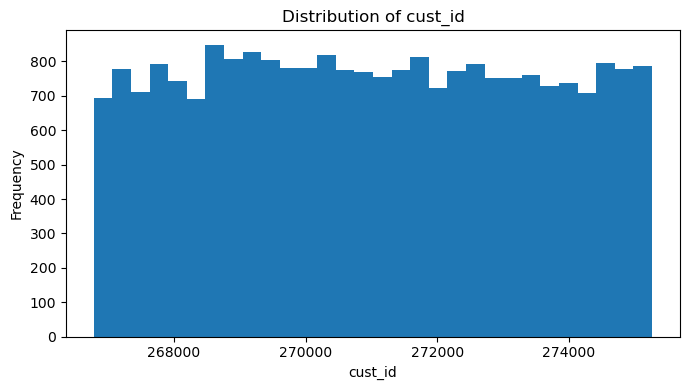

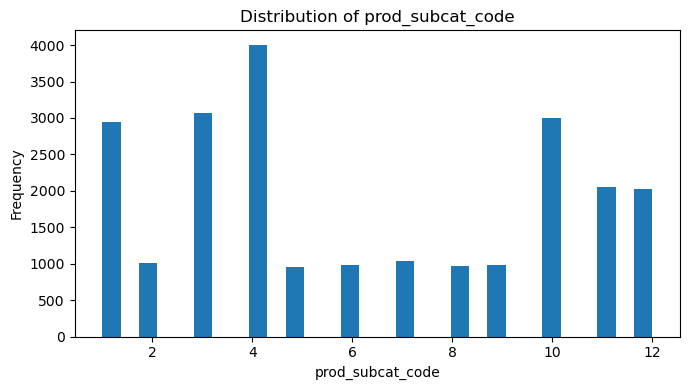

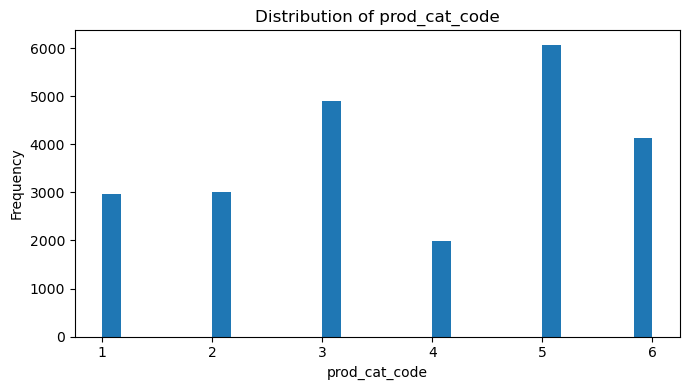

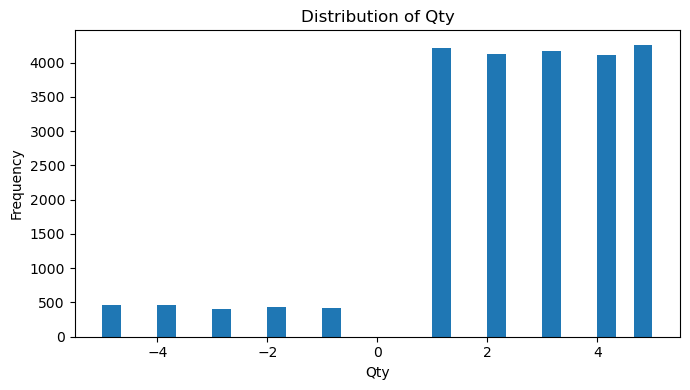

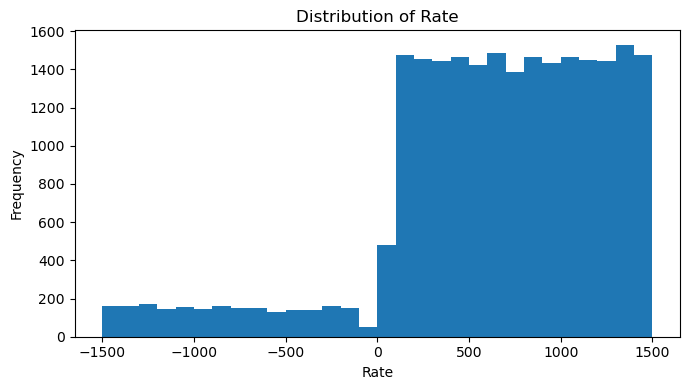

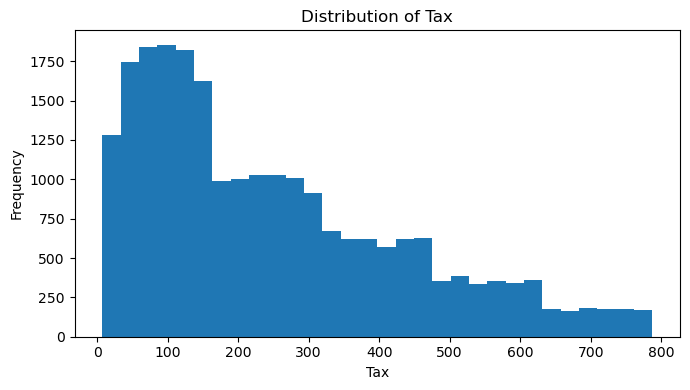

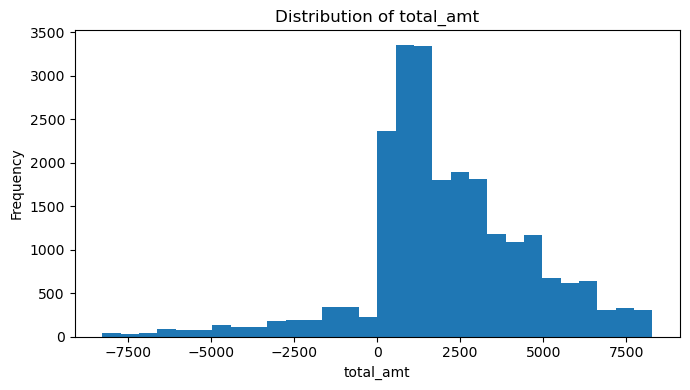

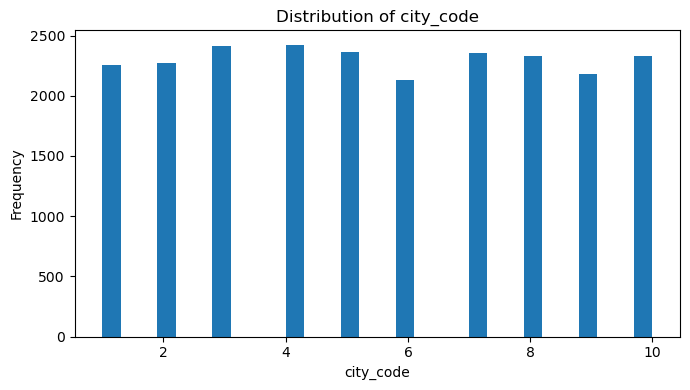

In [15]:
for col in continuous_cols:
    plt.figure(figsize=(7, 4))
    Customer_Final[col].plot(kind="hist", bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()


## 12. Frequency bar charts for categorical variables

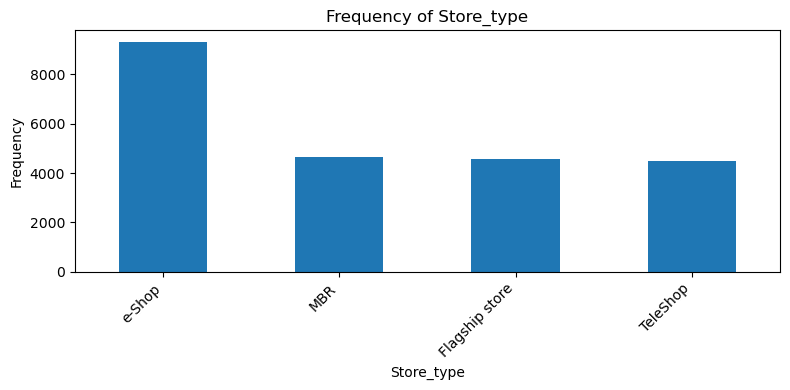

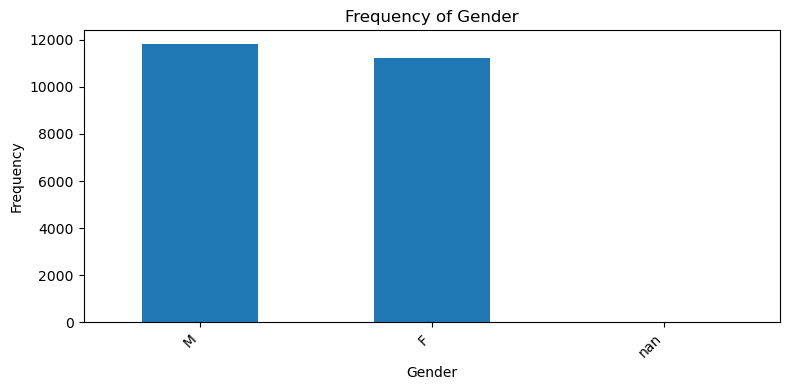

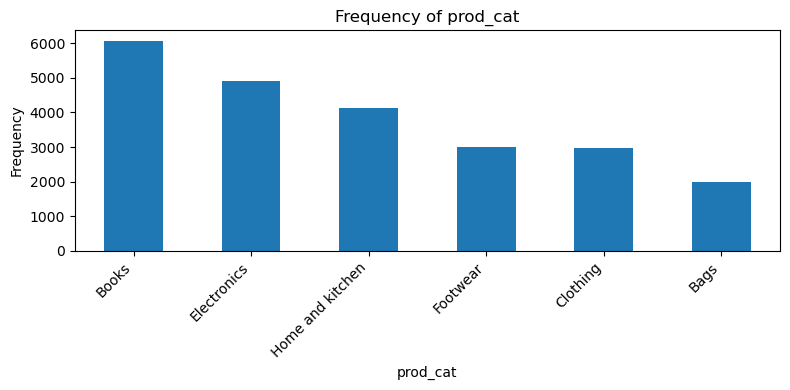

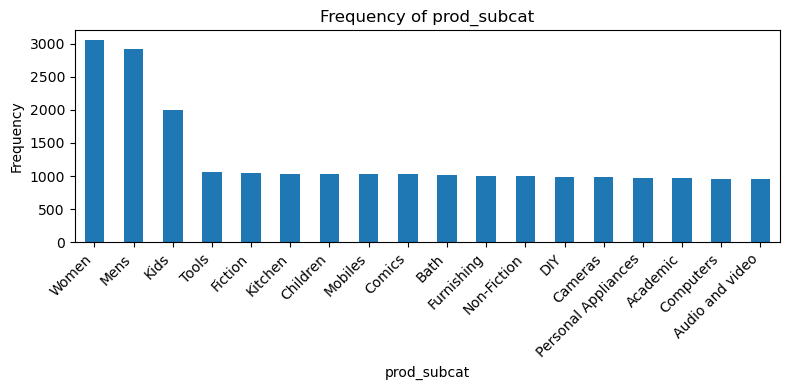

In [16]:
for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    Customer_Final[col].value_counts(dropna=False).plot(kind="bar")
    plt.title(f"Frequency of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


## 13. Q4(a) — Time period of available transaction data

In [17]:
start_date = Customer_Final["tran_date"].min()
end_date = Customer_Final["tran_date"].max()

print("Start date:", start_date.strftime("%d %B %Y"))
print("End date:", end_date.strftime("%d %B %Y"))


Start date: 25 January 2011
End date: 28 February 2014


### Answer — Q4(a)

The available transaction data covers **25 January 2011 to 28 February 2014**.


## 14. Q4(b) — Count of transactions with negative total amount

In [18]:
negative_count = (Customer_Final["total_amt"] < 0).sum()
print("Negative transaction records:", negative_count)


Negative transaction records: 2177


### Answer — Q4(b)

There are **2,177 transaction records** where `total_amt` is negative. These negative records are consistent with return/refund transactions in this retail dataset.


## 15. Q5 — Product-category popularity among females vs males

prod_cat,Bags,Books,Clothing,Electronics,Footwear,Home and kitchen
Gender,,,,,,
F,2362,7070,3425,5832,3716,4895
M,2346,7587,3748,6476,3555,5041


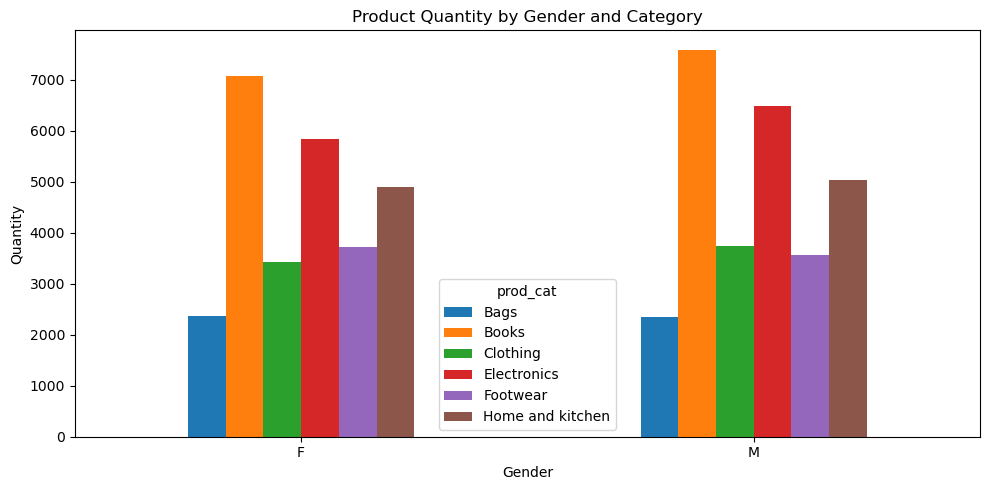

In [19]:
gender_category_qty = (
    Customer_Final
    .groupby(["Gender", "prod_cat"])["Qty"]
    .sum()
    .unstack(fill_value=0)
)

display(gender_category_qty)

gender_category_qty.plot(kind="bar", figsize=(10, 5))
plt.title("Product Quantity by Gender and Category")
plt.xlabel("Gender")
plt.ylabel("Quantity")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### Answer — Q5

Based on total quantity:

- **Male customers:** Books have the highest quantity.
- **Female customers:** Books also have the highest quantity overall; among the categories, Footwear is relatively stronger for females than for males.
- Books and Electronics are major categories for both genders.


## 16. Q6 — City code with maximum customers

In [20]:
city_customer_counts = (
    Customer_Final.groupby("city_code")["cust_id"]
    .nunique()
    .sort_values(ascending=False)
)

total_unique_customers = Customer_Final["cust_id"].nunique()
max_city = city_customer_counts.index[0]
max_city_customers = city_customer_counts.iloc[0]
max_city_pct = max_city_customers / total_unique_customers * 100

print("City code with maximum customers:", max_city)
print("Unique customers in that city:", max_city_customers)
print("Total unique customers:", total_unique_customers)
print(f"Percentage of customers: {max_city_pct:.2f}%")


City code with maximum customers: 3.0
Unique customers in that city: 576
Total unique customers: 5506
Percentage of customers: 10.46%


### Answer — Q6

**City Code 3** has the maximum number of unique customers: **576 customers**, representing approximately **10.46%** of the 5,506 unique customers in the merged dataset.


## 17. Q7 — Store type with maximum sales by value and quantity

In [21]:
store_summary = (
    Customer_Final
    .groupby("Store_type")
    .agg(
        total_value=("total_amt", "sum"),
        total_quantity=("Qty", "sum")
    )
    .sort_values("total_value", ascending=False)
)

display(store_summary)


,total_value,total_quantity
Store_type,,
e-Shop,"19,824,816.05",22763
Flagship store,"9,715,688.19",11133
MBR,"9,674,486.05",11194
TeleShop,"9,364,781.07",10984


### Answer — Q7

**e-Shop** has the maximum sales both:

- **By value:** approximately ₹19.82 million
- **By quantity:** approximately 22,763 units


## 18. Q8 — Amount earned from Electronics and Clothing through Flagship Stores

In [22]:
flagship_ec = Customer_Final[
    (Customer_Final["Store_type"] == "Flagship store") &
    (Customer_Final["prod_cat"].isin(["Electronics", "Clothing"]))
]

flagship_ec_summary = flagship_ec.groupby("prod_cat")["total_amt"].sum()
display(flagship_ec_summary.to_frame("total_amount"))

print("Combined amount:", flagship_ec["total_amt"].sum())


,total_amount
prod_cat,
Clothing,"1,194,423.23"
Electronics,"2,215,136.04"


Combined amount: 3409559.27


### Answer — Q8

For Flagship Stores:

- **Electronics:** ₹2,215,136.04
- **Clothing:** ₹1,194,423.23
- **Combined:** ₹3,409,559.27


## 19. Q9 — Amount earned from male customers under Electronics

In [23]:
male_electronics_amount = Customer_Final[
    (Customer_Final["Gender"] == "M") &
    (Customer_Final["prod_cat"] == "Electronics")
]["total_amt"].sum()

print(f"Male Electronics amount: ₹{male_electronics_amount:,.2f}")


Male Electronics amount: ₹5,703,109.42


### Answer — Q9

The total amount earned from **male customers under Electronics** is **₹5,703,109.42**.


## 20. Q10 — Customers with more than 10 unique transactions after removing negative transactions

In [24]:
positive_transactions = Customer_Final[
    Customer_Final["total_amt"] >= 0
]

customer_transaction_counts = (
    positive_transactions.groupby("cust_id")["transaction_id"]
    .nunique()
)

customers_more_than_10 = (customer_transaction_counts > 10).sum()

print("Customers with >10 unique transactions:", customers_more_than_10)


Customers with >10 unique transactions: 6


### Answer — Q10

After removing all transactions with negative amounts, **6 customers** have more than 10 unique transactions.


## 21. Q11 — Customers aged 25–35

### Age assumption

The case study asks for customers aged 25–35 but does not state the reference date for calculating age. To make the analysis reproducible, this notebook uses **1 January 2014** as the reference date.

Age is calculated from `DOB` using the difference between the reference date and date of birth.


In [25]:
reference_date = pd.Timestamp("2014-01-01")

Customer_Final["Age"] = (
    (reference_date - Customer_Final["DOB"]).dt.days / 365.25
)

age_25_35 = Customer_Final[
    (Customer_Final["Age"] >= 25) &
    (Customer_Final["Age"] <= 35)
].copy()

print("Rows for customers aged 25–35:", len(age_25_35))
print("Unique customers aged 25–35:", age_25_35["cust_id"].nunique())


Rows for customers aged 25–35: 10023
Unique customers aged 25–35: 2429


## 22. Q11(a) — Amount spent on Electronics and Books by customers aged 25–35

In [26]:
q11a = (
    age_25_35[
        age_25_35["prod_cat"].isin(["Electronics", "Books"])
    ]
    .groupby("prod_cat")["total_amt"]
    .sum()
)

display(q11a.to_frame("total_amount"))


,total_amount
prod_cat,
Books,"5,543,221.45"
Electronics,"4,680,689.39"


### Answer — Q11(a)

Using the 1-Jan-2014 age reference:

- **Books:** ₹5,543,221.45
- **Electronics:** ₹4,680,689.39


## 23. Q11(b) — Amount spent from 1-Jan-2014 to 1-Mar-2014

In [27]:
date_filtered = age_25_35[
    (age_25_35["tran_date"] >= pd.Timestamp("2014-01-01")) &
    (age_25_35["tran_date"] <= pd.Timestamp("2014-03-01"))
]

q11b_amount = date_filtered["total_amt"].sum()

print(f"Total amount spent: ₹{q11b_amount:,.2f}")


Total amount spent: ₹987,023.57


### Answer — Q11(b)

Using the same 25–35 age definition and the date range **1 January 2014 through 1 March 2014**, the total amount spent is **₹987,023.57**.


## 24. Additional analyst insights

In [28]:
# A few useful business-level summaries beyond the mandatory questions.

category_summary = (
    Customer_Final.groupby("prod_cat")
    .agg(
        transactions=("transaction_id", "nunique"),
        quantity=("Qty", "sum"),
        sales_value=("total_amt", "sum")
    )
    .sort_values("sales_value", ascending=False)
)

display(category_summary)

store_category = pd.pivot_table(
    Customer_Final,
    index="Store_type",
    columns="prod_cat",
    values="total_amt",
    aggfunc="sum",
    fill_value=0
)

display(store_category)


,transactions,quantity,sales_value
prod_cat,,,
Books,5486,14669,"12,822,694.04"
Electronics,4486,12308,"10,722,463.63"
Home and kitchen,3733,9941,"8,438,993.29"
Clothing,2676,7174,"6,251,137.49"
Footwear,2708,7274,"6,219,774.28"
Bags,1789,4708,"4,124,708.64"


prod_cat,Bags,Books,Clothing,Electronics,Footwear,Home and kitchen
Store_type,,,,,,
Flagship store,"870,548.83","2,488,205.85","1,194,423.23","2,215,136.04","1,234,806.56","1,712,567.68"
MBR,"848,678.68","2,496,039.19","1,287,686.33","2,107,514.56","1,112,163.72","1,822,403.57"
TeleShop,"789,181.06","2,545,005.06","1,241,834.36","1,973,338.83","1,235,719.29","1,579,702.48"
e-Shop,"1,616,300.07","5,293,443.93","2,527,193.56","4,426,474.20","2,637,084.71","3,324,319.57"


## 25. Key business insights

1. **e-Shop is the strongest store channel**, leading in both sales value and quantity.
2. **City Code 3** has the largest unique-customer base in the merged dataset, although it represents only about one-tenth of customers.
3. **Books and Electronics** are important categories across both genders.
4. Negative transaction amounts are substantial (**2,177 records**) and should be treated as returns/refunds when analyzing gross sales versus net sales.
5. Only **6 customers** exceed 10 unique positive transactions, suggesting a relatively small group of highly active customers.
6. The age-based analysis shows meaningful spending by the 25–35 segment in both **Books and Electronics**.
7. For future analysis, it would be useful to separate **gross sales, returns, and net sales** rather than interpreting the raw `total_amt` sum as sales only.


## 26. Final conclusion

The merged retail dataset provides a useful view of customer behavior, product demand, store performance, demographics, and transaction returns. The analysis indicates that e-Shop is the leading store type, City Code 3 has the highest customer concentration, and Books/Electronics are important categories for both genders. Negative transactions should be explicitly treated as returns when developing management KPIs.

**Important methodological note:** Q11 depends on an age-reference-date assumption because the supplied case study does not specify one. This notebook uses 1 January 2014 so that the calculation is transparent and reproducible.
